In [2]:
import pandas as pd
import csv
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



# ID 0002


In [3]:
def load_data(v):
    with open(f'mutation_dataset_10-06_v{v}\\simulacoes_com_erro.pkl', 'rb') as arquivo:
        simulacoes_com_erro = pickle.load(arquivo)

    trees_cblv = np.load(f'mutation_dataset_10-06_v{v}\\tree_data.npy')
    trees_cblv = np.delete(trees_cblv, simulacoes_com_erro, axis=0)

    #R_0_1, infectuos time and a taxa relativa 
    # Retornando a segunda coluna (coluna referente ao R_nought)
    # e em segunda transformando a lista em um np.array

    tabela_de_parametros = np.load(f'mutation_dataset_10-06_v{v}\\tabela_parametros.npy')
    tabela_de_parametros = np.delete(tabela_de_parametros, simulacoes_com_erro, axis=0)

    R_nought1 = np.array([sublist[0] for sublist in tabela_de_parametros])
    R_nought2 = np.array([sublist[1] for sublist in tabela_de_parametros])
    infectious_time = np.array([sublist[8] for sublist in tabela_de_parametros])
    proportion_tr11_tr22 = np.array([sublist[10] for sublist in tabela_de_parametros])
    
    rescale_factors = np.load(f'mutation_dataset_10-06_v{v}\\rescale_factor.npy')
    rescale_factors = np.delete(rescale_factors, simulacoes_com_erro)

    infectious_time_div_rescale = np.round(infectious_time / rescale_factors, 3)

    vectorized = np.column_stack((R_nought1, R_nought2, infectious_time_div_rescale))

    return trees_cblv, vectorized, rescale_factors

### Treinar a rede com CBLV de input apenas, e predizer R01, R02, e infectious_time
Fazer direito dessa vez

In [4]:
X, y, rescale_factors = load_data(0)

In [5]:
test_size = 10000
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    shuffle=False
)

In [6]:
scaler = StandardScaler()
y_train = scaler.fit_transform(y_train)
y_test = scaler.transform(y_test)

In [6]:
modelo = tf.keras.models.Sequential([
    layers.Input(X_train[0].shape),
    layers.Reshape((501, 2)),
    layers.Conv1D(filters = 50, kernel_size = 3, activation='relu'),
    layers.Conv1D(filters = 50, kernel_size = 10, activation='relu'),
    layers.MaxPooling1D(pool_size=10),
    layers.Conv1D(filters = 80, kernel_size = 10, activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='elu'),
    layers.Dense(32, activation='elu'),
    layers.Dense(16, activation='elu'),
    layers.Dense(8, activation='elu'),
    #layers.Dense(2, activation='elu'),
    layers.Dense(3, activation='linear')
    ])

In [7]:
modelo.compile(optimizer='adam',loss='mse',metrics=['mse'])
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 501, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 499, 50)        │           350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 490, 50)        │        25,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 40, 80)         │        40,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 80)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,435 (286.86 KB)

 Trainable params: 73,435 (286.86 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(monitor='val_mse', mode='min', patience=20, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_mse', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [9]:
history = modelo.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.1, callbacks=[early_stop, reduce_lr], verbose=1)

Epoch 1/150
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 121s 47ms/step - loss: 0.3230 - mse: 0.3230 - val_loss: 0.2098 - val_mse: 0.2098 - learning_rate: 0.0010
Epoch 2/150
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 129s 51ms/step - loss: 0.2020 - mse: 0.2020 - val_loss: 0.2408 - val_mse: 0.2408 - learning_rate: 0.0010
Epoch 3/150
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 118s 47ms/step - loss: 0.1899 - mse: 0.1899 - val_loss: 0.1832 - val_mse: 0.1832 - learning_rate: 0.0010
Epoch 4/150
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 116s 46ms/step - loss: 0.1754 - mse: 0.1754 - val_loss: 0.2133 - val_mse: 0.2133 - learning_rate: 0.0010
Epoch 5/150
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 119s 47ms/step - loss: 0.1677 - mse: 0.1677 - val_loss: 0.1661 - val_mse: 0.1661 - learning_rate: 0.0010
Epoch 6/150
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 113s 44ms/step - loss: 0.1624 - mse: 0.1624 - val_loss: 0.2025 - val_mse: 0.2025 - learning_rate: 0.0010
Epoch 7/150
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 116s 46ms/step - loss: 0.1599 - mse: 0.1599 - val_loss: 0.1940 - val_

In [10]:
path = "modelos\\0002"

modelo.save(path + "\\modelo.keras")

with open(path + "\\scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(path + "\\history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [ ]:
# CAREFULL! RUN THIS CELL ONLY ONCE
pred = modelo.predict(X_test)
pred = scaler.inverse_transform(pred)
pred[:, 1] *= rescale_factors[-test_size:]

y_test = scaler.inverse_transform(y_test)
y_test[:, 1] *= rescale_factors[-test_size:]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [12]:
mse_por_variavel = np.mean((pred - y_test) ** 2, axis=0)
print("MSE R01:", mse_por_variavel[0])
print("MSE R02:", mse_por_variavel[1])
print("MSE Inf:", mse_por_variavel[2])

MSE R01: 0.21044791820641157
MSE R02: 2.6653687402595065
MSE Inf: 0.2269118021317106


In [13]:
erros = np.abs(pred - y_test)
mae_por_variavel = np.mean(erros, axis=0)

print("MAE R01:", mae_por_variavel[0])
print("MAE R02:", mae_por_variavel[1])
print("MAE Inf:", mae_por_variavel[2])

MAE R01: 0.3262290135126605
MAE R02: 1.116166135425658
MAE Inf: 0.351586086497116


In [14]:
erro_relativo = np.mean(np.abs((pred - y_test) / y_test), axis=0)

print("MAPE R01:", erro_relativo[0])
print("MAPE R02:", erro_relativo[1])
print("MAPE Inf:", erro_relativo[2])

MAPE R01: 0.12056652615817536
MAPE R02: 0.16555851979638347
MAPE Inf: 0.0694438476379947


In [15]:
print(np.corrcoef(y_test[:,0], pred[:,0])[0,1])
print(np.corrcoef(y_test[:,1], pred[:,1])[0,1])
print(np.corrcoef(y_test[:,2], pred[:,2])[0,1])

0.9172747231558405
0.9065114759055041
0.9547303037143618


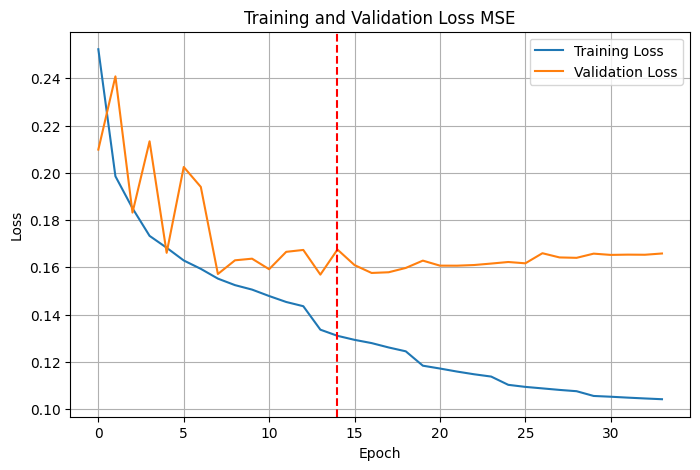

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss MSE')
plt.legend()
plt.grid(True)
plt.axvline(x=14, color='red', linestyle='--', linewidth=1.5)

plt.savefig(path + "\\loss_curve_MSE.pdf", format="pdf", bbox_inches="tight")
plt.savefig(path + "\\loss_curve_MSE.png", dpi=600, bbox_inches="tight")

plt.show()

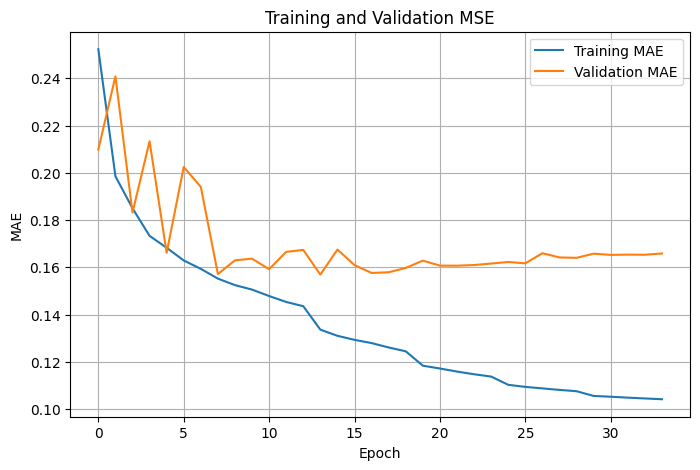

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['mse'], label='Training MAE')
plt.plot(history.history['val_mse'], label='Validation MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training and Validation MSE')
plt.legend()
plt.grid(True)
#plt.savefig(path + "\\loss_curve_MAE.pdf", format="pdf", bbox_inches="tight")
#plt.savefig(path + "\\loss_curve_MAE.png", dpi=600, bbox_inches="tight")

plt.show()